In [43]:
import scipy
import networkx as nx #A python library that seems helpful when dealing with graphs 
import matplotlib.pyplot as plt


In [44]:
## some useful functions 

def draw_graph( graph, position = False, size = (5,5)):

    plt.figure(figsize= size)

    if position == False: 
        
        nx.draw(
        graph,
        with_labels=True,
        node_color="skyblue",
        node_size=600,
        font_size=8,
        font_weight = 'bold',
        edge_color="gray",)

    else: 
        nx.draw(
            graph,
            pos= position,
            with_labels=True,
            node_color="skyblue",
            node_size=600,
            font_size=8,
            font_weight = 'bold',
            edge_color="gray",)      

    plt.show()

def convert_position_to_integers (integer_Graph, cols ):
    pos_int = {}
    for node in integer_Graph.nodes():
        node_mod = node- 1
        col_idx = node_mod % cols
        row_idx = node_mod // cols
        pos_int[node] = (col_idx, -row_idx)
    return pos_int


In [45]:
def local_complementation_integers (node, Graph, show_graph = False, gridlock = False, plot_size = (3,3), 
                                    columns = cols, position_int = pos_int):
    ##local complementation using a graph defined by integers, might work if defined by other manner but not sure
    
    # copy the graph 
    G = Graph.copy()

    #extract neighbor subgraph of node 
    neighbors = list(G.neighbors(node))
    G_sub = G.subgraph(neighbors)

    #complement the subgraph 
    G_sub_complement = nx.complement(G_sub)
    
    #delete existing edges between neighbors 
    G.remove_edges_from(G_sub.edges())
    ##Trouble shooting  print(list(G_sub.edges()))

    #add complement edges between naeighbors
    G.add_edges_from(G_sub_complement.edges())
    ##Trouble shooting  print(list(G_sub_complement.edges()) )

    #plot graph 
    if show_graph== True:
        if gridlock == False:
            draw_graph(G, size = plot_size)
        else:
            draw_graph(G, position_int, size = plot_size)

    return G
       
    ##Trouble shooting print(neighbors)    
    

In [52]:
## making functions to perform pauli measurements/ vertex deletions and lc's for grids defined by integers 

def Z_graph_operation(vertex_to_delete, graph_int, show_graph = False, gridlock = False, 
                      plot_size = (3,3), columns = cols, position_int = pos_int): 
    
    G = graph_int.copy()
    
    #delete vertex
    G.remove_node(vertex_to_delete)

    #plot graph 
    if show_graph== True:
        if gridlock == False:
            draw_graph(G, size = plot_size)
        else:
            draw_graph(G, position_int, size = plot_size)

    return G


def Y_graph_operation(vertex_to_delete, graph_int, show_graph = False, gridlock = False, 
                      plot_size = (3,3), columns = cols, position_int = pos_int): 
    
    G = graph_int.copy()

    #perform LC on vertex 
    G = local_complementation_integers(vertex_to_delete, G)
    
    #delete vertex
    G.remove_node(vertex_to_delete)

    #plot graph 
    if show_graph== True:
        if gridlock == False:
            draw_graph(G, size = plot_size)
        else:
            draw_graph(G, position_int, size = plot_size)

    return G

##add x operation make sure to check if pivot vertex is a neighbor 

def X_graph_operation(vertex_to_delete, graph_int, pivot, show_graph = False, gridlock = False, 
                      plot_size = (3,3), columns = cols, position_int = pos_int): 
    neighbors = list(graph_int.neighbors(vertex_to_delete))
                     
    if pivot not in neighbors:
        print("unable to perform operation, select new pivot vertex")
        return graph_int
    
    G = graph_int.copy()
    #draw_graph(G, size = plot_size)


    #perform LC's on vertex and pivot  
    G = local_complementation_integers(pivot, G)
    #draw_graph(G, size = plot_size)
    G = local_complementation_integers(vertex_to_delete, G)
    #draw_graph(G, size = plot_size)
    G = local_complementation_integers(pivot, G)
    #draw_graph(G, size = plot_size)
    
    #delete vertex
    G.remove_node(vertex_to_delete)

    #plot graph 
    if show_graph== True:
        if gridlock == False:
            draw_graph(G, size = plot_size)
        else:
            draw_graph(G, position_int, size = plot_size)

    return G

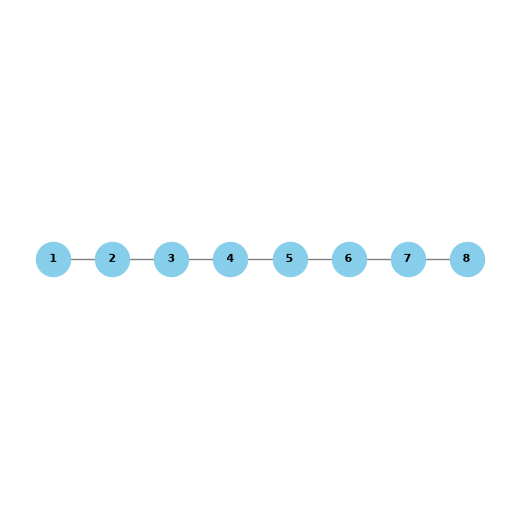

In [53]:

# 1. Generate an m x n grid graph (e.g., 5 rows, 5 columns)
rows = 1
cols = 8

G = nx.grid_2d_graph(rows, cols)

G_int = nx.convert_node_labels_to_integers(G, first_label=1)


pos_int = convert_position_to_integers( G_int, cols)

draw_graph(G_int, pos_int, (5,5))

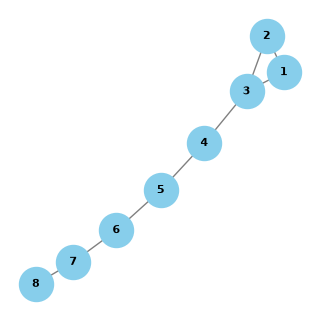

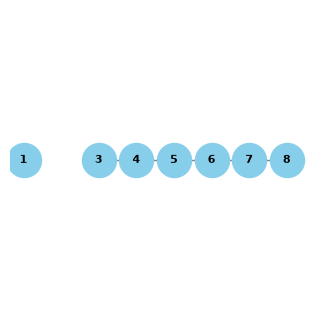

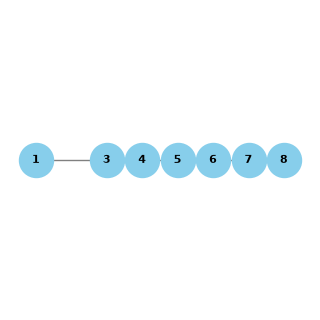

In [54]:
# trying to perform an x protocol on the graph to extract 2 pt (eg 3, 19)
    
G_int_lc = local_complementation_integers(2,G_int, gridlock= False, show_graph= True)
G_int_z = Z_graph_operation(2, G_int, gridlock= True, show_graph = True)
G_int_y = Y_graph_operation(2, G_int, gridlock = True, show_graph= True)



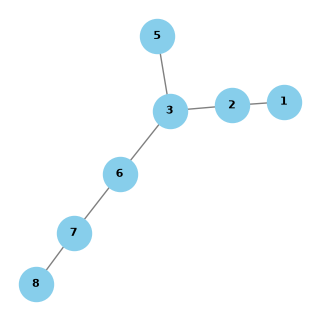

In [55]:
G_int_y = X_graph_operation(4, G_int, 5, show_graph= True)
